---
title: "Week 5 (CS 418 @ UIC)"
jupyter: python3
# Some code in this file was generated with LLM assistance.
# It is maintained and vetted by jxb@uic.edu.
# Please contact jxb@uic.edu with any issues or concerns.
execute:
  keep-ipynb: true
format:
  revealjs:
    fig-format: svg
    fig-width: 5
    fig-height: 3.09
    auto-stretch: false
    footer: '<img src="../assets/branding/uic-black-logo.svg" alt="UIC logo"> <img src="../assets/branding/cc-by-nc-sa-small.svg" alt="CC BY-NC-SA"> <span class="footer-text">CS 418, Intro to Data Science, Week 5</span><span class="footer-text"><a href="https://dodatascience.fun/slides/week5.html">dodatascience.fun/slides/week5</a></span>'
---

# Week 5 Slide Deck {.course-title}

## Visualizations

Jack Bandy
2026

---

# Topic Title Placeholder {.course-title .photo-title data-state="photo-title" background-image="../assets/orange-line-stops-better/stop05-clark-lake-a.jpg" background-size="cover"}

CS 418 · Week 5 · 🟠 Clark/Lake 🟠

---

# {.photo-only data-state="photo-only" background-image="../assets/orange-line-stops-better/stop05-clark-lake-a.jpg" background-size="cover"}

---

# Demo Content Slide

Placeholder content for Week 5.

- Visualization goals
- Encodings
- Chart selection

---

# Pie & Donut Charts {.section-header}

---

# Pie Charts Intuition

- A pie chart encodes **proportion** as **angle** (and area)
- Works okay for "roughly half" or "roughly a quarter"
- Difficult to compare multiple slices

---


# Pie vs. Bar Example {.image-frame-slide}

::: {.content-visible when-format="html"}
![](../assets/pi-donut-demos/piecharts-remix01.svg)
:::

::: {.content-visible when-format="pdf"}
![](../assets/pi-donut-demos/piecharts-remix01.svg)
:::

---

# Pie vs. Bar Example {.image-frame-slide}

::: {.content-visible when-format="html"}
![](../assets/pi-donut-demos/piecharts-remix02.svg)
:::

::: {.content-visible when-format="pdf"}
![](../assets/pi-donut-demos/piecharts-remix02.svg)
:::

---

# The Donut Chart

- A **donut chart** is a pie chart with the center cut out
- Maintain the "this is all part of a whole" message
- Area comparison

---

# Donut in the Wild: FIFA World Cup 2026 {.image-frame-slide}

::: {.content-visible when-format="html"}
![](../assets/pi-donut-demos/fifa-possession-example.jpeg)
:::

::: {.content-visible when-format="pdf"}
![](../assets/pi-donut-demos/fifa-possession-example.jpeg)
:::

---

# Recreating the FIFA Chart: Setup

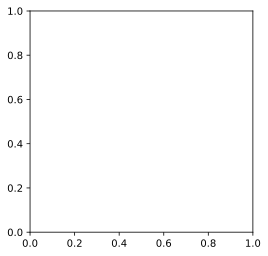

In [1]:
#| echo: true
#| output: false
import matplotlib.pyplot as plt

sizes  = [63, 27, 10]
labels = ['COL', 'COD', 'In Contest']
colors = ['#f5c800', '#0057a8', '#00a896']

fig, ax = plt.subplots(figsize=(4, 4))

---

# Recreating the FIFA Chart: Draw {.code-figure-slide}

In [2]:
#| echo: true
#| fig-alt: "Donut chart of FIFA World Cup 2026 Group K possession: Colombia 63% in yellow, DR Congo 27% in blue, In Contest 10% in teal"
ax.pie(sizes, labels=labels, autopct='%1.0f%%',
       colors=colors, startangle=90, counterclock=False,
       wedgeprops=dict(width=0.5), pctdistance=0.75)
ax.set_title('Possession', fontweight='bold')
plt.tight_layout()

<Figure size 480x296.64 with 0 Axes>

---

# Recreating the FIFA Chart {.code-figure-slide}

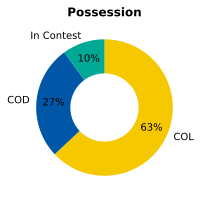

In [3]:
#| echo: true
#| fig-alt: 'Donut chart of FIFA World Cup 2026 Group K possession: Colombia 63% in yellow, DR Congo 27% in blue, In Contest 10% in teal'
import matplotlib.pyplot as plt

sizes  = [63, 27, 10]
labels = ['COL', 'COD', 'In Contest']
colors = ['#f5c800', '#0057a8', '#00a896']
_, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.0f%%', colors=colors,
       startangle=90, counterclock=False,
       wedgeprops=dict(width=0.5), pctdistance=0.75)
ax.set_title('Possession', fontweight='bold');

---

# Recreating the FIFA Chart: Polished

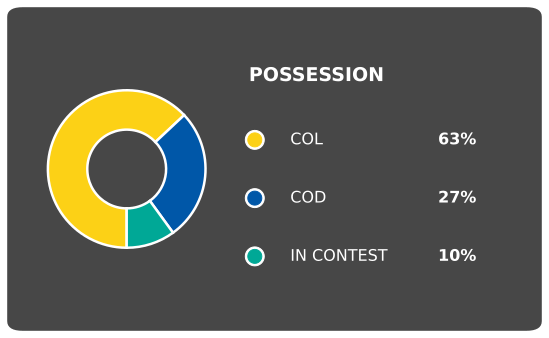

In [4]:
#| echo: false
#| fig-alt: 'Donut chart styled after the FIFA World Cup 2026 broadcast graphic: Colombia 63% yellow, DR Congo 27% blue, In Contest 10% teal, with legend on the right inside a semi-transparent dark rounded rectangle.'
#| out-width: 100%
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

phi = (1 + 5**0.5) / 2  # golden ratio ≈ 1.618
fig_h = 4.5
fig_w = fig_h * phi

fig = plt.figure(figsize=(fig_w, fig_h))
fig.patch.set_alpha(0)

bg = FancyBboxPatch(
    (0.02, 0.03), 0.96, 0.94,
    boxstyle="round,pad=0.03",
    facecolor=(0, 0, 0, 0.72),
    edgecolor="none",
    transform=fig.transFigure,
    zorder=0,
)
fig.add_artist(bg)

gs = gridspec.GridSpec(
    1, 2, width_ratios=[2, 3],
    left=0.03, right=0.97, bottom=0.05, top=0.95, wspace=0,
)
ax_d = fig.add_subplot(gs[0])
ax_l = fig.add_subplot(gs[1])
for ax in (ax_d, ax_l):
    ax.set_facecolor("none")

sizes  = [63, 27, 10]
labels = ["COL", "COD", "IN CONTEST"]
colors = ["#fcd116", "#0057a8", "#00a896"]

# startangle=-90 → Colombia starts at 6 o'clock, counterclock=False → runs clockwise to ~1 o'clock
ax_d.pie(
    sizes, colors=colors, startangle=-90, counterclock=False,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2.5),
)

ax_l.axis("off")
ax_l.set_xlim(0, 1)
ax_l.set_ylim(0, 1)

ax_l.text(0.08, 0.82, "POSSESSION", color="white", fontsize=19,
          fontweight="bold", va="center")

for i, (label, color, pct) in enumerate(zip(labels, colors, sizes)):
    y = 0.60 - i * 0.20
    # white ring behind colored fill
    ax_l.plot(0.10, y, "o", color="white",  markersize=19, zorder=4)
    ax_l.plot(0.10, y, "o", color=color,    markersize=14, zorder=5)
    ax_l.text(0.22, y, label,      color="white", fontsize=16, va="center")
    ax_l.text(0.72, y, f"{pct}%",  color="white", fontsize=16, va="center",
              fontweight="bold");

---

# Sources {.sources}

1. GitHub source: <https://github.com/jackbandy/data-science-fun/blob/main/docs/slides/week5.qmd>.
1. Last modified and compiled June 23, 22:13h Central (Chicago) time.
2. Pie vs. bar comparison: Schutz, [*Piecharts.svg*](https://commons.wikimedia.org/wiki/File:Piecharts.svg), Wikimedia Commons, 2008. [CC BY 1.0](https://creativecommons.org/licenses/by/1.0/).
3. Slides developed using materials from [Elena Zheleva](https://www.cs.uic.edu/~elena/) and [Gonzalo Bello Lander](https://cs.uic.edu/profiles/gonzalo-bello/), the Berkeley DS 100 team, Marine Carpuat, and Brian Ziebart.
4. Slide deck built with [Quarto](https://quarto.org/) revealjs.
5. Title font is Big Shoulders; Body font is [Libre Franklin](https://en.wikipedia.org/wiki/Franklin_Gothic#Libre_Franklin).